In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupKFold, train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score, precision_recall_curve, confusion_matrix, classification_report
from sklearn.feature_selection import RFECV, SelectFromModel
from sklearn.inspection import permutation_importance
import shap
import matplotlib.pyplot as plt


c:\Users\lenovo\Documents\GitHub\medical_data\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%pip install shap xgboost pandas numpy scikit-learn matplotlib

  Using cached shap-0.48.0-cp313-cp313-win_amd64.whl.metadata (25 kB)
  Using cached numpy-2.3.3-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached matplotlib-3.10.6-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached cloudpickle-3.1.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.9-cp313-cp313-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-11.3.0-cp313-cp313-win_amd64.whl.metadata (9.2 kB)
Using cached shap-0.48.0-cp


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
df = pd.read_csv("diabetic_data.csv")
print(df.shape)
df.head()


(101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [7]:
# Replace missing strings ('?') with NaN
df.replace('?', np.nan, inplace=True)

# Drop patient IDs not useful for prediction
df.drop(['encounter_id', 'patient_nbr'], axis=1, inplace=True)

# Convert target variable to binary: 1 = readmitted <30 days, 0 = otherwise
df['readmitted_flag'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
df.drop('readmitted', axis=1, inplace=True)


In [8]:
num_cols = [
    'time_in_hospital','num_lab_procedures','num_procedures',
    'num_medications','number_outpatient','number_emergency',
    'number_inpatient'
]
cat_cols = [c for c in df.columns if c not in num_cols + ['readmitted_flag']]


In [9]:
num_imputer = IterativeImputer(random_state=0)


In [10]:
cat_imputer = SimpleImputer(strategy='most_frequent')


In [11]:
num_pipe = Pipeline([
    ('imputer', num_imputer),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', cat_imputer),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])


In [12]:
X = df.drop('readmitted_flag', axis=1)
y = df['readmitted_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [13]:
models = {
    'RandomForest': RandomForestClassifier(class_weight='balanced', random_state=0, n_jobs=-1),
    'XGBoost': XGBClassifier(
        eval_metric='logloss', use_label_encoder=False,
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1])
    ),
    'SVM': SVC(probability=True, class_weight='balanced', random_state=0)
}


In [14]:
from sklearn.model_selection import RandomizedSearchCV

pipe = Pipeline([
    ('preproc', preprocessor),
    ('model', models['RandomForest'])
])

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 20, None]
}

search = RandomizedSearchCV(
    pipe, param_distributions=param_grid,
    scoring='roc_auc', n_iter=5, cv=3, n_jobs=-1, verbose=2
)
search.fit(X_train, y_train)

best_model = search.best_estimator_
print("Best ROC-AUC:", search.best_score_)


Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best ROC-AUC: 0.6634716453198141


In [15]:
calibrator = CalibratedClassifierCV(best_model, cv='prefit', method='isotonic')
calibrator.fit(X_test, y_test)
probs = calibrator.predict_proba(X_test)[:, 1]


c:\Users\lenovo\Documents\GitHub\medical_data\venv\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


AUC: 0.681 | Brier score: 0.095


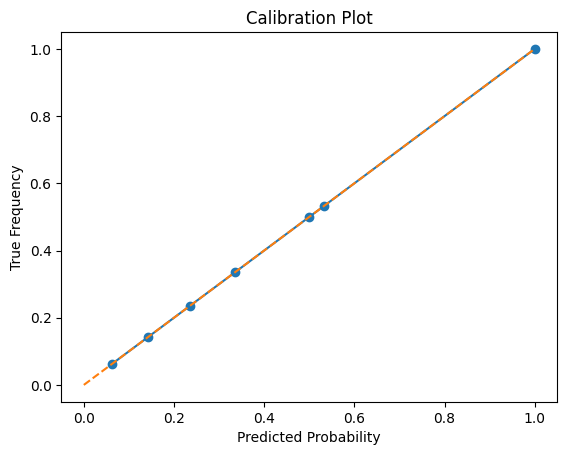

In [16]:
auc = roc_auc_score(y_test, probs)
brier = brier_score_loss(y_test, probs)
print(f"AUC: {auc:.3f} | Brier score: {brier:.3f}")

# Calibration curve
prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)
plt.plot(prob_pred, prob_true, 'o-')
plt.plot([0,1], [0,1], '--')
plt.xlabel("Predicted Probability")
plt.ylabel("True Frequency")
plt.title("Calibration Plot")
plt.show()


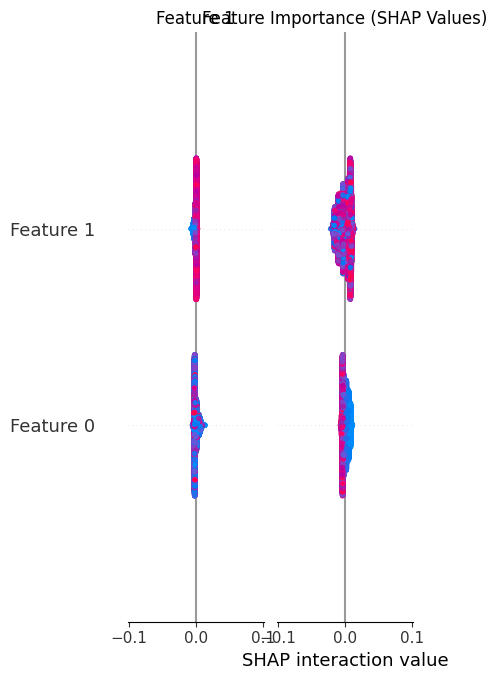

In [26]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Extract parts of pipeline
preprocessor = best_model.named_steps['preproc']
model = best_model.named_steps['model']

# Transform the test data
X_trans = preprocessor.transform(X_test)

# ✅ Convert sparse matrix to dense (this is the key fix)
if hasattr(X_trans, "toarray"):
    X_trans = X_trans.toarray()

# Convert to float (ensures SHAP compatibility)
X_trans = X_trans.astype(np.float64)

# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)

# Compute SHAP values
shap_values = explainer(X_trans)

# Plot SHAP summary (feature importance)
shap.summary_plot(shap_values, X_trans, show=False)
plt.title("Feature Importance (SHAP Values)")
plt.show()


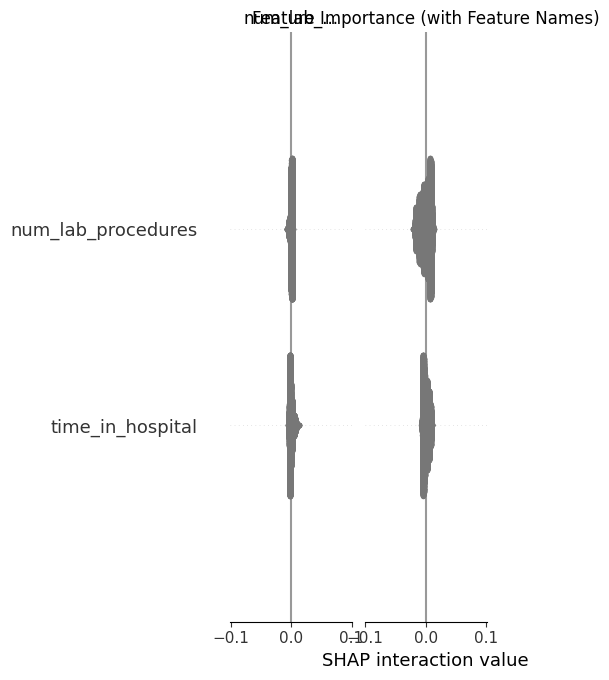

In [28]:
# Get feature names from your preprocessor
num_cols = preprocessor.transformers_[0][2]
cat_cols = preprocessor.transformers_[1][2]
cat_features = preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(cat_cols)
feature_names = np.concatenate([num_cols, cat_features])

# Plot with labels
shap.summary_plot(shap_values, features=X_trans, feature_names=feature_names, show=False)
plt.title("Feature Importance (with Feature Names)")
plt.show()


In [29]:
import joblib
joblib.dump(calibrator, 'readmission_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')


['preprocessor.pkl']